# Разведочный анализ данных: CIFAR-10 (изображения)

Базовый EDA для датасета CIFAR-10 (папка `cifar/cifar10/train`): просмотр примеров изображений по классам и усреднённого изображения.


Количество загруженных изображений (train sample): 128


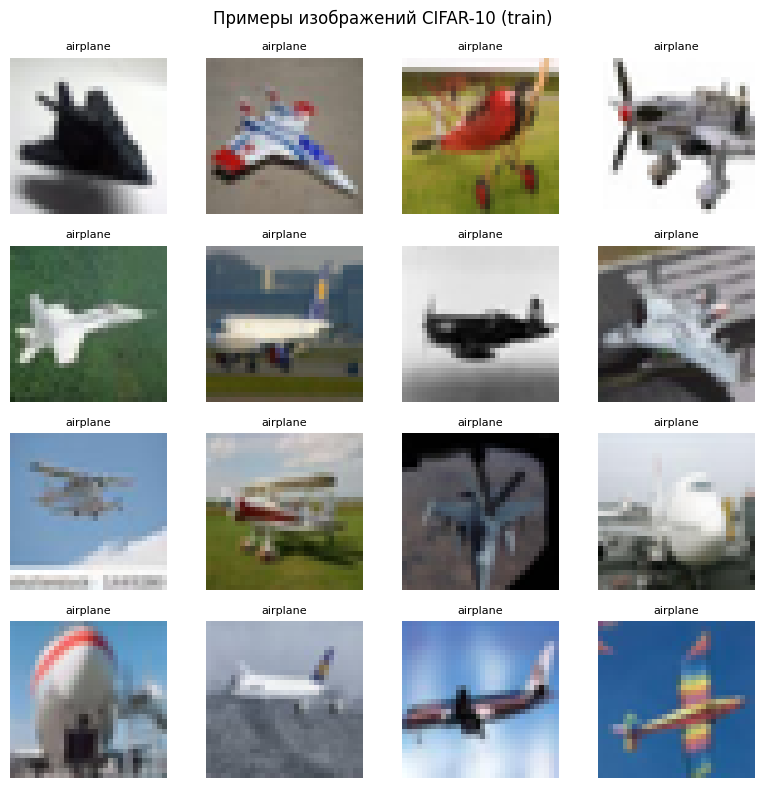

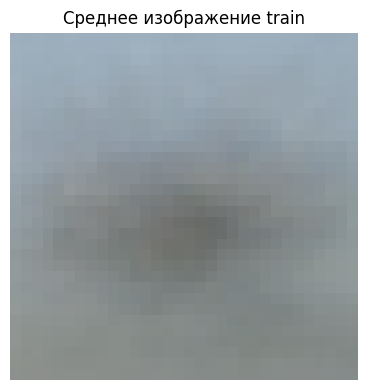

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


DATA_DIR = os.path.join("..", "datasets", "cifar", "cifar10")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")


def load_sample_images(root_dir, max_images=64):
    images = []
    labels = []
    class_names = sorted(os.listdir(root_dir))
    for cls in class_names:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            path = os.path.join(cls_dir, fname)
            try:
                img = Image.open(path).convert("RGB")
                images.append(np.array(img))
                labels.append(cls)
            except Exception:
                continue
            if len(images) >= max_images:
                return np.array(images), labels
    return np.array(images), labels


train_images, train_labels = load_sample_images(TRAIN_DIR, max_images=128)
print("Количество загруженных изображений (train sample):", len(train_images))

if len(train_images) > 0:
    plt.figure(figsize=(8, 8))
    for i in range(1, min(17, len(train_images) + 1)):
        plt.subplot(4, 4, i)
        plt.imshow(train_images[i - 1])
        plt.axis("off")
        plt.title(train_labels[i - 1], fontsize=8)
    plt.suptitle("Примеры изображений CIFAR-10 (train)")
    plt.tight_layout()
    plt.show()

    mean_image = train_images.mean(axis=0).astype(np.uint8)
    plt.figure(figsize=(4, 4))
    plt.imshow(mean_image)
    plt.title("Среднее изображение train")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
